In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np

In [3]:
df = pd.read_parquet("../../data/model_ready/flights_model_ready.parquet")
df.head()


,FlightDate,Airline,Origin,Dest,CRSDepTime,CRSElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,year,target,date,dep_hour,tmpf,vsby,sknt,p01i,relh,gust,DayOfWeek_num,month_sin,month_cos,dow_sin,dow_cos,Distance_std,tmpf_std,vsby_std,sknt_std,relh_std,gust_std,distance_origin_norm,has_precip,is_holiday,near_holiday_3d
0,2018-01-03,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,3,Wednesday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,Delayed,2018-01-03,10,27.0,10.0,6.000000,0.0,40.42,0.0,2,0.5,0.866025,0.974928,-0.222521,-1.181369,-1.795908,0.372,-0.268741,-1.032586,-0.532803,-506.21629,0,0,1
1,2018-01-04,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,4,Thursday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-04,10,24.1,10.0,14.166667,0.0,54.36,21.0,3,0.5,0.866025,0.433884,-0.900969,-1.181369,-1.949265,0.372,1.558113,-0.405039,1.744748,-506.21629,0,0,1
2,2018-01-05,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,5,Friday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8877A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-05,10,17.1,10.0,12.153846,0.0,55.51,0.0,4,0.5,0.866025,-0.433884,-0.900969,-1.181369,-2.319438,0.372,1.107853,-0.353268,-0.532803,-506.21629,0,0,0
3,2018-01-06,Endeavor Air Inc.,ATL,ABY,1037,59.0,145.0,2018,1,1,6,Saturday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8970D,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1136,1100-1159,1,2018,On time,2018-01-06,10,21.9,10.0,6.846154,0.0,57.02,0.0,5,0.5,0.866025,-0.974928,-0.222521,-1.181369,-2.065605,0.372,-0.079459,-0.285291,-0.532803,-506.21629,0,0,0
4,2018-01-07,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,7,Sunday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8980A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-07,10,21.9,10.0,7.384615,0.0,54.75,0.0,6,0.5,0.866025,-0.781831,0.623490,-1.181369,-2.065605,0.372,0.040993,-0.387482,-0.532803,-506.21629,0,0,0


In [4]:
df.shape

(14539250, 67)

In [5]:
df.isnull().sum().sort_values(ascending=False).head(20)

Tail_Number       51887
relh_std          15364
relh              15364
CRSElapsedTime        7
FlightDate            0
date                  0
sknt                  0
vsby                  0
tmpf                  0
dep_hour              0
year                  0
target                0
DistanceGroup         0
ArrTimeBlk            0
CRSArrTime            0
DepTimeBlk            0
DestWac               0
p01i                  0
gust                  0
DestStateFips         0
dtype: int64

In [ ]:
import sys
from pathlib import Path

# Get the root project directory (two levels up from the notebook)
project_root = Path.cwd().parents[1]  # notebooks/ → project root
scripts_path = project_root / "scripts"
sys.path.append(str(scripts_path))

# Now you can import your function
from sampling_split import sample_and_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



In [7]:
# train_df, val_df, test_df = sample_and_split(
#     df,
#     total_sample=500_000,
#     max_origin_frac=0.05,
#     max_region_frac=0.3,
#     test_size=0.2,
#     val_frac_of_train=0.25,
#     output_dir="../../data/model_ready/sampled_splits",
#     random_state=42
# )

In [10]:
train_df = pd.read_parquet("../../data/model_ready/sampled_splits/train.parquet")
val_df = pd.read_parquet("../../data/model_ready/sampled_splits/val.parquet")
test_df = pd.read_parquet("../../data/model_ready/sampled_splits/test.parquet")
print(f"train shape: {train_df.shape}")
print(f"val shape: {val_df.shape}")
print(f"test shape: {test_df.shape}")


train shape: (134639, 69)
val shape: (44880, 69)
test shape: (44880, 69)


In [22]:
train_df.target.value_counts(normalize=True)

target
On time      0.611792
Delayed      0.352840
Cancelled    0.035369
Name: proportion, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## Random Forest Model Baseline

Features based off of EDA:
- Airline
- DeptTimeBlk
- DistanceGroup
- Month
- Dep_Hour
- Weather
- DayofWeek

In [ ]:
FEATURES = ["Quarter", "Month", "DayofMonth", "DayOfWeek", "dep_hour", "DepTimeBlk",
    "Airline", "Origin", "Dest", "Distance", "DistanceGroup",
    "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

TARGET = "target"


In [ ]:
# Split categorical vs numerical
categorical_features = [
    "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
]

numeric_features = [
    "Quarter", "Month", "DayofMonth", "dep_hour",
    "Distance", "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)



In [14]:
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)


In [15]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])


In [16]:
# Convert categorical columns to string (needed for OneHotEncoder)
for col in categorical_features:
    train_df[col] = train_df[col].astype(str)
    val_df[col]   = val_df[col].astype(str)
    test_df[col]  = test_df[col].astype(str)

# # Fill numeric NaNs with 0
for col in numeric_features:
    train_df[col] = train_df[col].fillna(0)
    val_df[col]   = val_df[col].fillna(0)
    test_df[col]  = test_df[col].fillna(0)

# Optional: fill categorical NaNs with "missing"
for col in categorical_features:
    train_df[col] = train_df[col].fillna("missing")
    val_df[col]   = val_df[col].fillna("missing")
    test_df[col]  = test_df[col].fillna("missing")


In [17]:
pipeline.fit(train_df[FEATURES], train_df[TARGET])


/Users/arelyvasquez/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['DepTimeBlk', 'Airline',
                                                   'Origin', 'Dest',
                                                   'DistanceGroup',
                                                   'DayOfWeek']),
                                                 ('num', 'passthrough',
                                                  ['Quarter', 'Month',
                                                   'DayofMonth', 'dep_hour',
                                                   'Distance', 'tmpf', 'vsby',
                                                   'sknt', 'p01i', 'relh',
                                                   'gust'])])),
                ('rf',
                 RandomForestClassifier(max_depth=15, n_estimators=80,
                                        n_jobs=-1, random_state=42))])

In [18]:
# Predictions
y_pred = pipeline.predict(test_df[FEATURES])

# Metrics
print("Classification Report:\n")
print(classification_report(test_df[TARGET], y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(test_df[TARGET], y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)



Classification Report:

              precision    recall  f1-score   support

   Cancelled      1.000     0.006     0.013      1587
     Delayed      0.646     0.113     0.192     15836
     On time      0.634     0.972     0.767     27457

    accuracy                          0.635     44880
   macro avg      0.760     0.364     0.324     44880
weighted avg      0.651     0.635     0.538     44880


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled   0.006301  0.129175  0.864524
Delayed     0.000000  0.113097  0.886903
On time     0.000000  0.028335  0.971665


Test Accuracy: 0.635

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled         10      205     1372
Delayed            0     1791    14045
On time            0      778    26679

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.006301  0.129175  0.864524
Delayed     0.000000  0.113097  0.886903
On time     0.000000  0.028335  0.971665


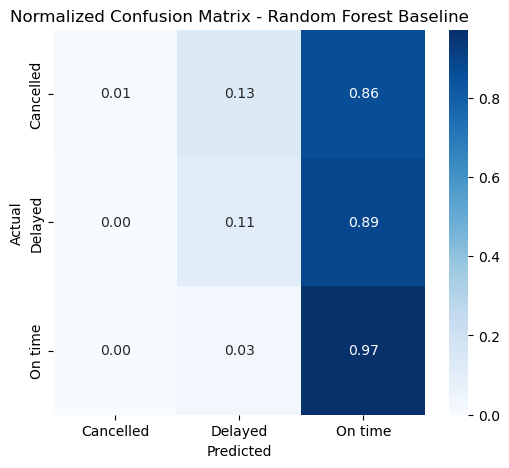


Classification Report:
              precision    recall  f1-score   support

   Cancelled      1.000     0.006     0.013      1587
     Delayed      0.646     0.113     0.192     15836
     On time      0.634     0.972     0.767     27457

    accuracy                          0.635     44880
   macro avg      0.760     0.364     0.324     44880
weighted avg      0.651     0.635     0.538     44880



In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(test_df[FEATURES])
y_true = test_df[TARGET]

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))


Given that the class is imbalanced, a dummy classifier model who would predict all "On time" would give us a 61% accuracy with this training dataset. This baseline model performed at a 63.5% accuracy, meaning this is slightly better than a dummy model. 

From these stats, we can see that:
- the model almost never predicts cancellations, but when it does it is correct. (1.0 precision for cancellations)
- But out of the 1587 only .006% were found, which means the model is bad for predicting cancellations

- For the delays, it also misses most delays with only finding about .113 % of the delayed flights

- For the on time flights, the model predicts on time for almost everything. But this can be problematic because it won't really be able to predict any calcellations or delays if it only predicts on time. 


The classifier effectively learned that predicting “on time” is the safest strategy for maximizing overall correctness. As a result, it rarely predicts cancellations or delays. This behavior explains the high recall for on-time flights and the extremely low recall for the other categories.

The Random Forest classifier achieved an overall accuracy of 63.5%. However, a deeper analysis of class-level metrics reveals that the model is heavily biased toward predicting flights as on time. While recall for on-time flights is very high (97.2%), the model performs poorly in identifying cancelled and delayed flights, with recall values of 0.6% and 11.3% respectively. This indicates that the classifier frequently misses disruption events, which are often the most operationally important outcomes.

Although the model’s accuracy appears reasonable, accuracy is not an appropriate metric for this problem due to strong class imbalance. Since the majority of flights are on time, a model could predict every flight as on time and still achieve over 60% accuracy. Therefore, metrics such as recall and F1-score provide a more meaningful evaluation of performance, particularly for minority classes like cancellations.

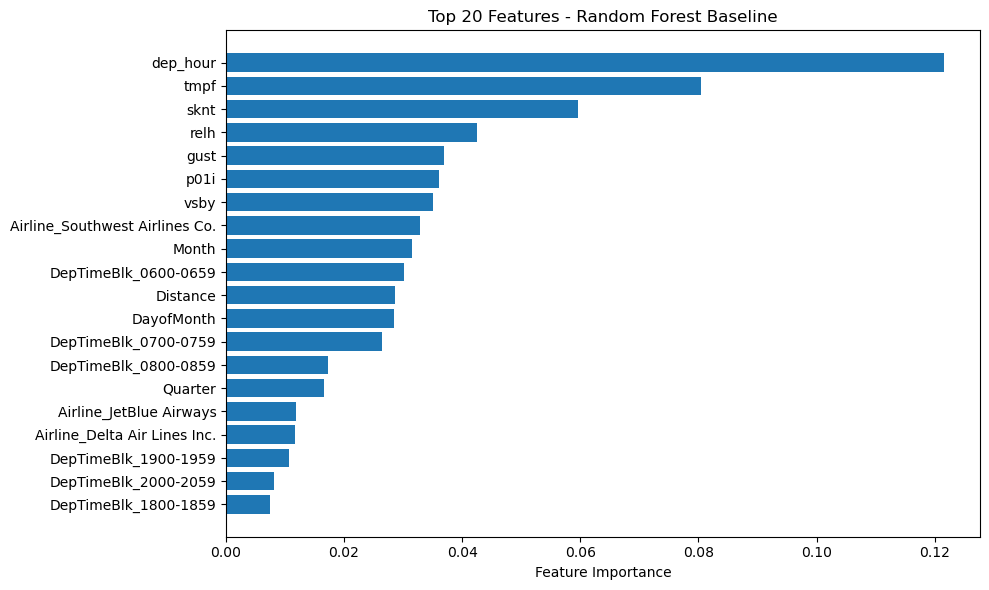

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_features = np.concatenate([cat_features, numeric_features])

# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = all_features[indices]
sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest Baseline")
plt.tight_layout()
plt.show()


We evaluated three approaches to predict flight status in a highly imbalanced dataset: a baseline Random Forest, a model using SMOTE to oversample minority classes, and a model with class weights to penalize misclassification of rare events. 
The baseline model achieved 64% accuracy but performed poorly on minority classes, with recall of near 0% for cancellations and 11% for delays, demonstrating that overall accuracy alone is misleading in this context. Applying SMOTE improved minority class detection, increasing recall for cancellations to 34% and delays to 45%, though this came at the expense of on-time recall (64%) and overall accuracy (56%). 

The class-weighted model achieved similar gains, with slightly higher recall for delays (53%) and comparable recall for cancellations (36%), while maintaining slightly better alignment between minority detection and operational relevance. These results illustrate the tradeoff between maximizing overall accuracy and capturing rare but operationally critical disruptions. From an airline perspective, models that more accurately predict cancellations and delays—even at the cost of occasional false positives—are preferable, since missing actual disruptions has far greater operational consequences.

| Model        | Cancel Recall | Delay Recall | On-time Recall | Accuracy |
| ------------ | ------------- | ------------ | -------------- | -------- |
| Baseline     | ~0%           | 11%          | 91%            | 64%      |
| SMOTE        | 34%           | 45%          | 64%            | 56%      |
| Class Weight | 36%           | 53%          | 61%            | 57%      |


### Goal: Catch as many cancellations and delays as possible, even if it generates false alarms.

Focus: Recall for minority classes, especially cancellations.

Accuracy is secondary.
